In [2]:
%pip install -q mne mne-features EntropyHub PyWavelets networkx imbalanced-learn torch

In [37]:
import numpy as np
import pandas as pd
import mne
from scipy.io import loadmat
from pathlib import Path

"""
Unified ErrP loader for:
- BNCI .mat files (original notebook format)
- EDF recordings with trigger/stim channels
- CSV recordings with EEG columns + trigger column
- DSI text exports (handled like CSV when they contain tabular data)

Outputs:
  X: (num_samples, num_channels, num_timesteps)
  y: (num_samples,), where 1 = ErrP, 0 = non-ErrP
"""

# --- configurable epoch window (seconds) ---
PRE_S = 0.2
POST_S = 0.8

# --- Trigger maps for PsychoPy games (outcome triggers only) ---
TRIGGER_MAPS = {
    "fruit": {
        "non_errp": {1, 2},          # correct_left, correct_right
        "errp": {3, 4, 5, 6, 7, 8, 9, 10},
        "ignore": {11, 12, 13, 14},  # cue/block/session markers
    },
    "racing": {
        "non_errp": {1, 2},          # correct_left, correct_right
        "errp": {3, 4, 5, 6, 7},
        "ignore": {8, 9, 10, 11},    # cues/block/session markers
    },
    # Trigger map for psychopy/errpGamePlain.py
    # 1 = non-error, 2/3/4 = error variants
    "errp_plain": {
        "non_errp": {1},
        "errp": {2, 3, 4},
        "ignore": set(),
    },
    # Compatibility map for BNCI dataset used in the original notebook
    "bnci22": {
        "non_errp": {5, 10},
        "errp": {6, 9},
        "ignore": set(),
    },
}


def _unwrap(x):
    while isinstance(x, np.ndarray) and x.dtype == object and x.size == 1:
        x = x.flat[0]
    return x


def _cell_to_list(cell):
    cell = _unwrap(cell)
    if isinstance(cell, np.ndarray) and cell.dtype == object:
        return [_unwrap(el) for el in cell.flat]
    if isinstance(cell, (list, tuple)):
        return [_unwrap(el) for el in cell]
    return [cell]


def _get_struct_field(struct, name):
    s = _unwrap(struct)

    if hasattr(s, name):
        return _unwrap(getattr(s, name))

    if isinstance(s, np.void) and s.dtype.names and (name in s.dtype.names):
        return _unwrap(s[name])
    if isinstance(s, np.ndarray) and s.dtype.names and (name in s.dtype.names):
        return _unwrap(s[name])

    if isinstance(s, dict) and name in s:
        return _unwrap(s[name])

    if isinstance(s, np.ndarray) and s.size > 0:
        first = _unwrap(s.flat[0])
        return _get_struct_field(first, name)

    raise KeyError(f"Field '{name}' not found on struct with type {type(s)}")


def _maybe_squeeze_vector(x):
    arr = np.array(x)
    if arr.ndim > 2:
        arr = np.squeeze(arr)
    if arr.ndim == 2 and 1 in arr.shape:
        arr = arr.reshape(-1)
    return arr


def _extract_event_pos_typ(event_struct):
    pos_raw = _get_struct_field(event_struct, 'POS')
    typ_raw = _get_struct_field(event_struct, 'TYP')

    pos = _maybe_squeeze_vector(pos_raw).astype(int)
    typ = _maybe_squeeze_vector(typ_raw).astype(int)

    if pos.size and typ.size:
        if pos.max() <= 64 and typ.max() > 1000:  # likely swapped
            pos, typ = typ, pos

    return pos, typ


def _epoch_from_events(eeg_tc, event_pos, event_typ, fs, trigger_map, pre_s=PRE_S, post_s=POST_S):
    """
    eeg_tc: EEG array shaped (T, C)
    event_pos: sample indices
    event_typ: trigger codes
    """
    pre_samp = int(round(pre_s * fs))
    post_samp = int(round(post_s * fs))
    win_len = pre_samp + post_samp

    errp_codes = set(trigger_map['errp'])
    non_errp_codes = set(trigger_map['non_errp'])
    keep_codes = errp_codes | non_errp_codes

    X_segments, y_labels = [], []
    T, _ = eeg_tc.shape

    for p, t in zip(event_pos, event_typ):
        code = int(t)
        if code not in keep_codes:
            continue

        start, end = int(p) - pre_samp, int(p) + post_samp
        if start < 0 or end > T:
            continue

        seg = eeg_tc[start:end, :]
        if seg.shape[0] != win_len:
            continue

        X_segments.append(seg.T)
        y_labels.append(1 if code in errp_codes else 0)

    if not X_segments:
        raise RuntimeError("No valid epochs found from selected trigger codes and window.")

    X = np.stack(X_segments, axis=0)
    y = np.array(y_labels, dtype=int)
    return X, y


def _find_trigger_column(df):
    candidates = [
        'TRG', 'Trigger', 'TRIGGER', 'trigger', 'STI', 'stim', 'status', 'Status',
        'event', 'Event', 'marker', 'Marker'
    ]
    for c in candidates:
        if c in df.columns:
            return c
    return None


def _find_time_column(df):
    candidates = ['t', 'time', 'Time', 'timestamp', 'Timestamp']
    for c in candidates:
        if c in df.columns:
            return c
    return None


def _csv_or_dsi_to_epochs(path, trigger_map, pre_s=PRE_S, post_s=POST_S, default_sfreq=300.0):
    df = pd.read_csv(path)
    trig_col = _find_trigger_column(df)
    if trig_col is None:
        raise ValueError(
            f"Could not find trigger column in {path}. "
            f"Expected one of TRG/Trigger/STI/status/event/marker."
        )

    time_col = _find_time_column(df)

    drop_cols = [trig_col]
    if time_col is not None:
        drop_cols.append(time_col)
    eeg_cols = [c for c in df.columns if c not in drop_cols]

    if not eeg_cols:
        raise ValueError(f"No EEG columns found in {path} after removing trigger/time columns.")

    trig = pd.to_numeric(df[trig_col], errors='coerce').fillna(0).astype(int).values
    eeg = df[eeg_cols].values.astype(np.float32)  # (T, C)

    if time_col is not None:
        t = pd.to_numeric(df[time_col], errors='coerce').values
        dt = np.diff(t)
        dt = dt[np.isfinite(dt) & (dt > 0)]
        fs = float(1.0 / np.median(dt)) if dt.size else float(default_sfreq)
    else:
        fs = float(default_sfreq)

    # Trigger hub pulses are usually code then 0, so use rising-edge style detection
    event_pos = []
    event_typ = []
    prev = 0
    for i, code in enumerate(trig):
        if code > 0 and (prev == 0 or code != prev):
            event_pos.append(i)
            event_typ.append(code)
        prev = code

    if len(event_pos) == 0:
        raise RuntimeError(f"No non-zero trigger onsets found in {path}.")

    return _epoch_from_events(eeg, np.array(event_pos), np.array(event_typ), fs, trigger_map, pre_s=pre_s, post_s=post_s)


def _edf_to_epochs(path, trigger_map, pre_s=PRE_S, post_s=POST_S):
    raw = mne.io.read_raw_edf(path, preload=True, verbose='ERROR')
    fs = float(raw.info['sfreq'])

    # Prefer explicit stim channel when present
    stim_candidates = [c for c in raw.ch_names if c.lower() in ('trigger', 'trg', 'sti', 'status', 'stim')]

    if stim_candidates:
        events = mne.find_events(raw, stim_channel=stim_candidates[0], min_duration=0.0, verbose=False)
    else:
        # Fallback to annotations
        events, _ = mne.events_from_annotations(raw, verbose=False)

    if events is None or len(events) == 0:
        raise RuntimeError(f"No events found in EDF file: {path}")

    event_pos = events[:, 0].astype(int)
    event_typ = events[:, 2].astype(int)

    eeg = raw.get_data(picks='eeg').T.astype(np.float32)  # (T, C)
    return _epoch_from_events(eeg, event_pos, event_typ, fs, trigger_map, pre_s=pre_s, post_s=post_s)


def _mat_bnci_to_epochs(path, trigger_map, pre_s=PRE_S, post_s=POST_S):
    m = loadmat(path, squeeze_me=False, struct_as_record=False)

    for k in ('run', 'runs', 'Run', 'Runs'):
        if k in m:
            run_cell = m[k]
            break
    else:
        raise KeyError(f"Could not find a 'run' cell/array in {list(m.keys())}")

    runs = _cell_to_list(run_cell)
    X_segments, y_labels = [], []

    for run_struct in runs:
        eeg = _get_struct_field(run_struct, 'eeg')
        header = _get_struct_field(run_struct, 'header')

        fs = int(np.array(_unwrap(_get_struct_field(header, 'SampleRate'))).squeeze())
        event = _get_struct_field(header, 'EVENT')
        pos, typ = _extract_event_pos_typ(event)

        eeg = np.array(eeg)
        if eeg.ndim > 2:
            eeg = np.squeeze(eeg)
        if eeg.ndim != 2:
            raise ValueError(f"Unexpected EEG shape: {eeg.shape}")

        Xi, yi = _epoch_from_events(eeg, pos, typ, fs, trigger_map, pre_s=pre_s, post_s=post_s)
        X_segments.append(Xi)
        y_labels.append(yi)

    if not X_segments:
        raise RuntimeError("No valid epochs found in MAT runs.")

    X = np.concatenate(X_segments, axis=0)
    y = np.concatenate(y_labels, axis=0)
    return X, y


def load_errp_eeg(path, task='fruit', pre_s=PRE_S, post_s=POST_S, default_sfreq=300.0):
    """
    Generic ErrP loader.

    Args:
      path: input file path (.mat, .edf, .csv, .dsi)
      task: one of {'fruit', 'racing', 'bnci22'}
      pre_s/post_s: epoch window around trigger onset

    Returns:
      X: (N, C, T)
      y: (N,) where 1=ErrP, 0=non-ErrP
    """
    task_key = task.lower()
    if task_key not in TRIGGER_MAPS:
        raise ValueError(f"Unknown task '{task}'. Expected one of {list(TRIGGER_MAPS.keys())}")
    trigger_map = TRIGGER_MAPS[task_key]

    p = Path(path)
    suffix = p.suffix.lower()

    if suffix == '.mat':
        X, y = _mat_bnci_to_epochs(path, trigger_map, pre_s=pre_s, post_s=post_s)
    elif suffix == '.edf':
        X, y = _edf_to_epochs(path, trigger_map, pre_s=pre_s, post_s=post_s)
    elif suffix in ('.csv', '.dsi'):
        # .dsi here assumes a text/tabular export that pandas can read
        X, y = _csv_or_dsi_to_epochs(path, trigger_map, pre_s=pre_s, post_s=post_s, default_sfreq=default_sfreq)
    else:
        raise ValueError(
            f"Unsupported file extension '{suffix}'. "
            f"Use .mat, .edf, .csv, or .dsi text export."
        )

    return X.astype(np.float32), y.astype(int)

In [5]:
# Colab Drive mount (safe to run in Colab; no-op elsewhere)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Google Drive mounted at /content/drive")
except Exception as e:
    print("Not running in Google Colab or Drive mount unavailable.")
    print(f"Details: {e}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted at /content/drive


In [38]:
# Cell 3: Data selection + file-level participant/session mapping
# supported file types: .edf, .csv, .dsi (text export), .mat

from collections import defaultdict

DATA_PATH = "/content/drive/MyDrive/data/Errp Game"
TASK_TYPE = "errp_plain"  # task options: 'fruit', 'racing', 'errp_plain', 'bnci22'

# File-level mapping mode: every loaded file is treated as one participant/session.
# PARTICIPANTS is retained for compatibility but not used in this mode.
PARTICIPANTS = []

SUPPORTED_EXTS = {".edf"}

def _file_id(fp: Path, root: Path):
    # Stable file-based identifier used for both participant and session labels.
    try:
        rel = fp.relative_to(root)
        return str(rel.with_suffix("")).lower()
    except Exception:
        return str(fp.with_suffix(""))

base_path = Path(DATA_PATH)

if base_path.is_file():
    candidate_files = [base_path]
elif base_path.is_dir():
    candidate_files = sorted(
        p for p in base_path.rglob("*")
        if p.is_file() and p.suffix.lower() in SUPPORTED_EXTS
    )
else:
    raise FileNotFoundError(f"DATA_PATH not found: {DATA_PATH}")

# No participant-name filtering: evaluate every discovered file.
selected_files = candidate_files

if not selected_files:
    raise RuntimeError(
        "No matching input files found. "
        f"Checked {len(candidate_files)} file(s) under {DATA_PATH}."
    )

X_list, y_list = [], []
loaded_files = []
failed_files = []

sample_participants = []
sample_sessions = []
participant_file_counts = defaultdict(int)

for fp in selected_files:
    try:
        Xi, yi = load_errp_eeg(str(fp), task=TASK_TYPE, pre_s=PRE_S, post_s=POST_S)
        X_list.append(Xi)
        y_list.append(yi)
        loaded_files.append(fp)

        file_id = _file_id(fp, base_path)
        participant_id = file_id
        session_id = file_id

        sample_participants.extend([participant_id] * len(yi))
        sample_sessions.extend([session_id] * len(yi))
        participant_file_counts[participant_id] += 1
    except UnicodeDecodeError as e:
        failed_files.append((fp, f"Unicode decode error (likely binary .dsi). Export to CSV/EDF first. {e}"))
    except Exception as e:
        failed_files.append((fp, str(e)))

if not X_list:
    msg_lines = [
        "No files could be loaded into epochs.",
        f"Selected files: {len(selected_files)}",
        "Failures:",
    ]
    msg_lines.extend([f"  - {p}: {err}" for p, err in failed_files[:20]])
    raise RuntimeError("\n".join(msg_lines))

X = np.concatenate(X_list, axis=0)
y = np.concatenate(y_list, axis=0)
sample_participants = np.array(sample_participants)
sample_sessions = np.array(sample_sessions)

unique_participants = np.unique(sample_participants)
unique_sessions = np.unique(sample_sessions)

print(f"Task mapping: {TASK_TYPE}")
print("Participant mode: file-level (each file is one participant/session)")
print(f"Selected files: {len(selected_files)}")
print(f"Loaded files: {len(loaded_files)}")
print(f"Failed files: {len(failed_files)}")
print(f"Detected participants: {len(unique_participants)}")
print(f"Detected sessions/files: {len(unique_sessions)}")

if loaded_files:
    print("\nLoaded:")
    for p in loaded_files:
        print(f"  - {p}")

if failed_files:
    print("\nFailed:")
    for p, err in failed_files:
        print(f"  - {p}")
        print(f"    reason: {err}")

print("\nFiles per participant:")
for pid in sorted(participant_file_counts):
    print(f"  - {pid}: {participant_file_counts[pid]}")

print(f"\nFinal dataset shapes: X={X.shape}, y={y.shape}")
print(f"Metadata shapes: sample_participants={sample_participants.shape}, sample_sessions={sample_sessions.shape}")

Task mapping: errp_plain
Participant mode: file-level (each file is one participant/session)
Selected files: 10
Loaded files: 10
Failed files: 0
Detected participants: 10
Detected sessions/files: 10

Loaded:
  - /content/drive/MyDrive/data/Errp Game/03_09_26_errpgame_omer_raw.edf
  - /content/drive/MyDrive/data/Errp Game/26_02_03_errp_churek_raw.edf
  - /content/drive/MyDrive/data/Errp Game/26_02_03_errp_erin_raw.edf
  - /content/drive/MyDrive/data/Errp Game/26_02_23_game_andrew_raw.edf
  - /content/drive/MyDrive/data/Errp Game/26_02_23_game_erin_raw.edf
  - /content/drive/MyDrive/data/Errp Game/26_02_23_game_omer_raw.edf
  - /content/drive/MyDrive/data/Errp Game/26_02_25_game_yichen_raw.edf
  - /content/drive/MyDrive/data/Errp Game/26_02_27_game_nihitha_raw.edf
  - /content/drive/MyDrive/data/Errp Game/26_03_02_game_andrew_raw.edf
  - /content/drive/MyDrive/data/Errp Game/xavier_3_3_26_game_raw.edf

Files per participant:
  - 03_09_26_errpgame_omer_raw: 1
  - 26_02_03_errp_churek_raw:

In [39]:
import numpy as np
unique_labels, counts = np.unique(y,return_counts=True)
print("Dataset label counts (1 for ErrP trial, 0 for correct trial):")
print(np.asarray((unique_labels, counts)).T)

Dataset label counts (1 for ErrP trial, 0 for correct trial):
[[   0 4152]
 [   1 1375]]


In [40]:
import numpy as np
import mne
from scipy.stats import kurtosis
from mne.filter import filter_data

def preprocess_eeg(eeg_data: np.ndarray, sfreq: float) -> np.ndarray:
    """
    EEG preprocessing tuned for short epochs (e.g., 300 samples at 512 Hz):
      1. Band-pass (1-20 Hz) with IIR (short-epoch-safe).
      2. Detect bad channels (kurtosis-based).
      3. Interpolate bads per sample (requires montage).
      4. Apply Common Average Reference (CAR).

    Why IIR here: FIR designs for very low cutoffs can exceed epoch length and distort short trials.
    """
    processed = np.asarray(eeg_data, dtype=np.float64).copy()
    num_samples, num_channels, num_timesteps = processed.shape

    # Use valid channel names from 10-20 montage to avoid interpolation failures.
    montage = mne.channels.make_standard_montage("standard_1020")
    ch_names_all = montage.ch_names[:num_channels]

    # ---------------------------------------------------------------------
    # 1. Band-pass filter all data together
    #    IIR avoids long FIR kernel warnings on short epochs.
    # ---------------------------------------------------------------------
    processed = filter_data(
        processed.reshape(-1, num_timesteps),
        sfreq=float(sfreq),
        l_freq=1.0,
        h_freq=20.0,
        method="iir",
        iir_params={"order": 4, "ftype": "butter"},
        phase="zero",
        verbose="ERROR",
    ).reshape(num_samples, num_channels, num_timesteps)

    # ---------------------------------------------------------------------
    # 2. Compute kurtosis and detect bads per sample
    # ---------------------------------------------------------------------
    kurt_vals = kurtosis(processed, axis=2, fisher=False)
    bad_masks = np.zeros_like(kurt_vals, dtype=bool)

    for i in range(num_samples):
        th = np.mean(kurt_vals[i]) + 3 * np.std(kurt_vals[i])
        bad_masks[i] = kurt_vals[i] > th

    # ---------------------------------------------------------------------
    # 3. Interpolate bad channels per sample
    # ---------------------------------------------------------------------
    for i in range(num_samples):
        if np.any(bad_masks[i]):
            data = processed[i]
            info = mne.create_info(ch_names=ch_names_all, sfreq=float(sfreq), ch_types="eeg")
            raw = mne.io.RawArray(data, info, verbose="ERROR")
            raw.set_montage(montage, match_case=False, verbose="ERROR")
            raw.info["bads"] = [ch_names_all[j] for j, bad in enumerate(bad_masks[i]) if bad]
            raw.interpolate_bads(reset_bads=True, verbose="ERROR")
            processed[i] = raw.get_data()

    # ---------------------------------------------------------------------
    # 4. Common Average Reference (CAR) in batch
    # ---------------------------------------------------------------------
    processed -= processed.mean(axis=1, keepdims=True)

    return processed.astype(np.float32)

In [23]:
cleaned_data = preprocess_eeg(
    X, sfreq=512.0
)
print(cleaned_data.shape)

(251, 12, 300)


In [41]:
import os
import subprocess
import sys
from pathlib import Path

def _is_colab_runtime() -> bool:
    return "google.colab" in sys.modules

def _repo_has_feature_module(root: Path) -> bool:
    return (root / "classify" / "feature.py").exists()

def _resolve_repo_root() -> Path:
    # 1) Honor explicit override first.
    env_root = os.environ.get("USER_REPO_ROOT")
    if env_root:
        p = Path(env_root).expanduser().resolve()
        if _repo_has_feature_module(p):
            return p

    # 2) Preferred defaults by runtime.
    if _is_colab_runtime():
        preferred = [
            Path("/content/ErrP"),
            Path("/content/drive/MyDrive/ErrP"),
            Path("/content/drive/MyDrive/Programming/ErrP"),
            Path("/content/drive/MyDrive/Colab Notebooks/ErrP"),
        ]
    else:
        preferred = [
            Path.cwd(),
            Path.cwd().parent,
            Path("/home/derick/Programming/ErrP"),
        ]

    for p in preferred:
        p = p.expanduser().resolve()
        if _repo_has_feature_module(p):
            return p

    # 3) If on Colab and repo missing, clone to /content/ErrP.
    if _is_colab_runtime():
        clone_target = Path("/content/ErrP")
        if not clone_target.exists():
            subprocess.run(
                ["git", "clone", "https://github.com/Neurotech-BCI/ErrP.git", str(clone_target)],
                check=True,
            )
            print(f"Cloned repo to {clone_target}")
        else:
            subprocess.run(["git", "-C", str(clone_target), "pull"], check=True)
            print(f"Repo already present at {clone_target}, pulled latest")
        return clone_target.resolve()

    raise FileNotFoundError(
        "Could not resolve ErrP repo root. Set USER_REPO_ROOT to your local ErrP path."
    )

REPO_ROOT = _resolve_repo_root()
os.environ["USER_REPO_ROOT"] = str(REPO_ROOT)
print(f"Using USER_REPO_ROOT={REPO_ROOT}")

Using USER_REPO_ROOT=/content/ErrP


In [42]:
import importlib
import importlib.util
import os
import sys
import types
from pathlib import Path
import numpy as np

# Optional env override (works for local VS Code and Colab).
USER_REPO_ROOT = os.environ.get("USER_REPO_ROOT")

def _repo_has_feature_module(root: Path) -> bool:
    return (root / "classify" / "feature.py").exists()

def _find_repo_root() -> Path:
    # 1) Explicit overrides first.
    explicit_candidates = [
        USER_REPO_ROOT,
        os.environ.get("REPO_ROOT"),
    ]
    for candidate in explicit_candidates:
        if not candidate:
            continue
        p = Path(candidate).expanduser().resolve()
        if _repo_has_feature_module(p):
            return p
        raise FileNotFoundError(
            f"Configured repo root does not contain classify/feature.py: {p}"
        )

    # 2) Fast direct checks for common locations.
    direct_candidates = [
        Path.cwd(),
        Path.cwd().parent,
        Path.cwd().parent.parent,
        Path("/home/derick/Programming/ErrP"),
        Path("/content/ErrP"),
        Path("/content/drive/MyDrive/ErrP"),
        Path("/content/drive/MyDrive/Programming/ErrP"),
        Path("/content/drive/MyDrive/Colab Notebooks/ErrP"),
    ]
    seen = set()
    for p in direct_candidates:
        rp = p.expanduser().resolve()
        if rp in seen:
            continue
        seen.add(rp)
        if _repo_has_feature_module(rp):
            return rp

    # 3) Recursive fallback in likely parent roots.
    search_roots = [
        Path.cwd(),
        Path("/content"),
        Path("/home/derick/Programming"),
        Path.home(),
    ]
    for root in search_roots:
        if not root.exists():
            continue
        for fp in root.rglob("classify/feature.py"):
            return fp.parent.parent.resolve()

    raise FileNotFoundError(
        "Could not find ErrP repo root containing classify/feature.py. "
        "Set USER_REPO_ROOT to your ErrP folder path before running this cell."
    )

def _import_local_feature_wrapper(repo_root: Path):
    """Load classify.feature without executing classify/__init__.py."""
    repo_root = repo_root.resolve()
    pkg_dir = repo_root / "classify"
    feature_path = pkg_dir / "feature.py"
    if not feature_path.exists():
        raise FileNotFoundError(f"Missing feature module at: {feature_path}")

    if str(repo_root) not in sys.path:
        sys.path.insert(0, str(repo_root))

    # Remove stale classify modules that point to another checkout.
    stale_pkg = sys.modules.get("classify")
    stale_file = getattr(stale_pkg, "__file__", "") if stale_pkg else ""
    stale_path = getattr(stale_pkg, "__path__", []) if stale_pkg else []
    path_mismatch = stale_path and str(pkg_dir) not in [str(Path(p).resolve()) for p in stale_path]
    file_mismatch = stale_file and str(pkg_dir) not in str(stale_file)
    if stale_pkg and (file_mismatch or path_mismatch):
        for name in list(sys.modules):
            if name == "classify" or name.startswith("classify."):
                sys.modules.pop(name, None)

    # Create a lightweight package shell so relative imports in feature.py work.
    if "classify" not in sys.modules:
        pkg = types.ModuleType("classify")
        pkg.__path__ = [str(pkg_dir)]
        pkg.__package__ = "classify"
        sys.modules["classify"] = pkg

    module_name = "classify.feature"
    existing = sys.modules.get(module_name)
    if existing is not None:
        loaded_from = str(Path(getattr(existing, "__file__", "")).resolve()) if getattr(existing, "__file__", None) else ""
        if loaded_from != str(feature_path.resolve()):
            sys.modules.pop(module_name, None)

    if module_name not in sys.modules:
        spec = importlib.util.spec_from_file_location(module_name, str(feature_path))
        if spec is None or spec.loader is None:
            raise ImportError(f"Could not create import spec for {feature_path}")
        feature_mod = importlib.util.module_from_spec(spec)
        sys.modules[module_name] = feature_mod
        spec.loader.exec_module(feature_mod)
    else:
        feature_mod = sys.modules[module_name]

    return feature_mod.FeatureWrapper

REPO_ROOT = _find_repo_root()
FeatureWrapper = _import_local_feature_wrapper(REPO_ROOT)
wrapper = FeatureWrapper()
print(f"Using local repo root: {REPO_ROOT}")

desired_features = [
    "median_frequency",
    "power_bandwidth",
    "alpha_bandpower",
    "beta_bandpower",
    "theta_bandpower",
    "delta_bandpower",
    "fft_max_value",
    "rms",
    "std",
    "time_max_peak",
    "time_min_peak",
    "max_peak_value",
    "min_peak_value",
    "prominence",
    "mean_frequency",
    "snr1",
    "snr",
    "sinad",
    "peak_location",
    "wavelet_energy_2_4",
    "wavelet_energy_4_8",
]

print(
    "Shape of EEG data before computing features "
    "(number_of_samples, number_of_channels, number_of_timesteps):\n"
    f"{cleaned_data.shape}"
)
print()
features = np.stack(
    [wrapper.compute_features(sample, 512.0, desired_features=desired_features) for sample in cleaned_data]
)
print(
    "Shape of EEG data after computing features "
    "(number_of_samples, number_of_channels, number_of_features):\n"
    f"{features.shape}"
)

Using local repo root: /content/ErrP
Shape of EEG data before computing features (number_of_samples, number_of_channels, number_of_timesteps):
(251, 12, 300)

Shape of EEG data after computing features (number_of_samples, number_of_channels, number_of_features):
(251, 12, 21)


In [44]:
import numpy as np
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, balanced_accuracy_score

# ------------------------------------------------------------------
# Keep training data in sync with current labels (y).
# Priority: features -> cleaned_data -> raw X
# ------------------------------------------------------------------
if "y" not in globals():
    raise RuntimeError("y is not defined. Run Cell 4 first.")

n_y = len(y)
source_name = None

if "features" in globals() and hasattr(features, "shape") and features.shape[0] == n_y:
    X_flat = features.reshape(features.shape[0], -1)
    source_name = "features"
elif "cleaned_data" in globals() and hasattr(cleaned_data, "shape") and cleaned_data.shape[0] == n_y:
    X_flat = cleaned_data.reshape(cleaned_data.shape[0], -1)
    source_name = "cleaned_data (fallback)"
elif "X" in globals() and hasattr(X, "shape") and X.shape[0] == n_y:
    X_flat = X.reshape(X.shape[0], -1)
    source_name = "raw X (fallback)"
else:
    shapes = {
        "y": n_y,
        "features": features.shape[0] if "features" in globals() and hasattr(features, "shape") else None,
        "cleaned_data": cleaned_data.shape[0] if "cleaned_data" in globals() and hasattr(cleaned_data, "shape") else None,
        "X": X.shape[0] if "X" in globals() and hasattr(X, "shape") else None,
    }
    raise RuntimeError(
        "No feature/source array matches y length. "
        "Re-run Cells 6, 7, and 9 after loading data. "
        f"Current lengths: {shapes}"
    )

print(f"Using source for classification: {source_name} with {X_flat.shape[0]} samples")

# Ensure metadata arrays are NumPy arrays and aligned.
if "sample_participants" not in globals() or len(sample_participants) != n_y:
    sample_participants = np.array(["all"] * n_y)
else:
    sample_participants = np.asarray(sample_participants)

if "sample_sessions" not in globals() or len(sample_sessions) != n_y:
    sample_sessions = np.array([f"sample_{i}" for i in range(n_y)])
else:
    sample_sessions = np.asarray(sample_sessions)

def _evaluate_subset(X_sub, y_sub, subset_name, random_state=42):
    unique, counts = np.unique(y_sub, return_counts=True)
    class_count = {int(k): int(v) for k, v in zip(unique, counts)}

    if len(unique) < 2:
        return {
            "subset": subset_name,
            "n_samples": int(len(y_sub)),
            "class_0": class_count.get(0, 0),
            "class_1": class_count.get(1, 0),
            "status": "skipped_single_class",
        }

    min_class = int(np.min(counts))
    n_splits = min(5, min_class)
    if n_splits < 2:
        return {
            "subset": subset_name,
            "n_samples": int(len(y_sub)),
            "class_0": class_count.get(0, 0),
            "class_1": class_count.get(1, 0),
            "status": "skipped_too_few_samples",
        }

    cv_splitter = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    model = Pipeline(
        [
            ("scaler", StandardScaler()),
            ("svc", SVC(kernel="linear", C=1.0, class_weight="balanced")),
        ]
    )

    outputs = []
    for train_idx, test_idx in cv_splitter.split(X_sub, y_sub):
        X_train, X_test = X_sub[train_idx], X_sub[test_idx]
        y_train, y_test = y_sub[train_idx], y_sub[test_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        outputs.extend((pred, real, index) for pred, real, index in zip(y_pred, y_test, test_idx))

    outputs = sorted(outputs, key=lambda x: x[2])
    pred_pairs = [(pred, real) for pred, real, _ in outputs]

    y_pred_all = np.array([p for p, _ in pred_pairs])
    y_true_all = np.array([t for _, t in pred_pairs])

    return {
        "subset": subset_name,
        "n_samples": int(len(y_sub)),
        "class_0": class_count.get(0, 0),
        "class_1": class_count.get(1, 0),
        "status": "ok",
        "mean_accuracy": float(accuracy_score(y_true_all, y_pred_all)),
        "mean_precision": float(precision_score(y_true_all, y_pred_all, average="weighted", zero_division=0)),
        "mean_recall": float(recall_score(y_true_all, y_pred_all, average="weighted", zero_division=0)),
        "mean_f1": float(f1_score(y_true_all, y_pred_all, average="weighted", zero_division=0)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true_all, y_pred_all)),
        "predictions": pred_pairs,
    }

all_metrics = {}

# 1) Cross-participant/session pooled result
all_metrics["pooled_all"] = _evaluate_subset(X_flat, y, "pooled_all")

# 2) Per-participant results
for pid in sorted(np.unique(sample_participants)):
    idx = np.where(sample_participants == pid)[0]
    all_metrics[f"participant::{pid}"] = _evaluate_subset(X_flat[idx], y[idx], f"participant::{pid}")

# 3) Per-session/file results
for sid in sorted(np.unique(sample_sessions)):
    idx = np.where(sample_sessions == sid)[0]
    all_metrics[f"session::{sid}"] = _evaluate_subset(X_flat[idx], y[idx], f"session::{sid}")

# Keep backward compatibility for downstream cells (confusion matrix, per-class report).
metrics = all_metrics["pooled_all"]

rows = []
for key, m in all_metrics.items():
    row = {
        "subset_key": key,
        "status": m.get("status"),
        "n_samples": m.get("n_samples"),
        "class_0": m.get("class_0"),
        "class_1": m.get("class_1"),
        "balanced_accuracy": m.get("balanced_accuracy"),
        "mean_accuracy": m.get("mean_accuracy"),
        "mean_f1": m.get("mean_f1"),
    }
    rows.append(row)

results_df = pd.DataFrame(rows).sort_values(["status", "subset_key"]).reset_index(drop=True)
print("Evaluation summary (pooled + per-participant + per-session):")
print(results_df.to_string(index=False))

if metrics.get("status") == "ok":
    pooled_summary = {k: v for k, v in metrics.items() if k not in ("predictions", "subset") }
    print("\nPooled metrics used by downstream cells:")
    print(pooled_summary)
else:
    print("\nPooled evaluation was skipped. Check class balance / sample counts.")

Using source for classification: raw X (fallback) with 5527 samples
Evaluation summary (pooled + per-participant + per-session):
                             subset_key status  n_samples  class_0  class_1  balanced_accuracy  mean_accuracy  mean_f1
participant::03_09_26_errpgame_omer_raw     ok        548      420      128           0.515476       0.656934 0.655025
  participant::26_02_03_errp_churek_raw     ok        572      414      158           0.582217       0.664336 0.664985
    participant::26_02_03_errp_erin_raw     ok        535      409      126           0.667152       0.734579 0.742635
  participant::26_02_23_game_andrew_raw     ok        550      406      144           0.478004       0.580000 0.587965
    participant::26_02_23_game_erin_raw     ok        593      438      155           0.680638       0.762226 0.759327
    participant::26_02_23_game_omer_raw     ok        544      418      126           0.542322       0.667279 0.670371
  participant::26_02_25_game_yichen_ra

In [45]:
from collections import defaultdict
correct = defaultdict(int)
total = defaultdict(int)

for pred, real in metrics["predictions"]:
    total[real] += 1
    if pred == real:
        correct[real] += 1
accuracy_per_class = {cls: correct[cls] / total[cls] for cls in total}
for k, v in accuracy_per_class.items():
    print(f"Accuracy for Class {k}: {(v*100):.1f}%")
print(f"Balanced Accuracy: {(np.mean(list(accuracy_per_class.values()))*100):.1f}%")


Accuracy for Class 0: 68.1%
Accuracy for Class 1: 54.5%
Balanced Accuracy: 61.3%


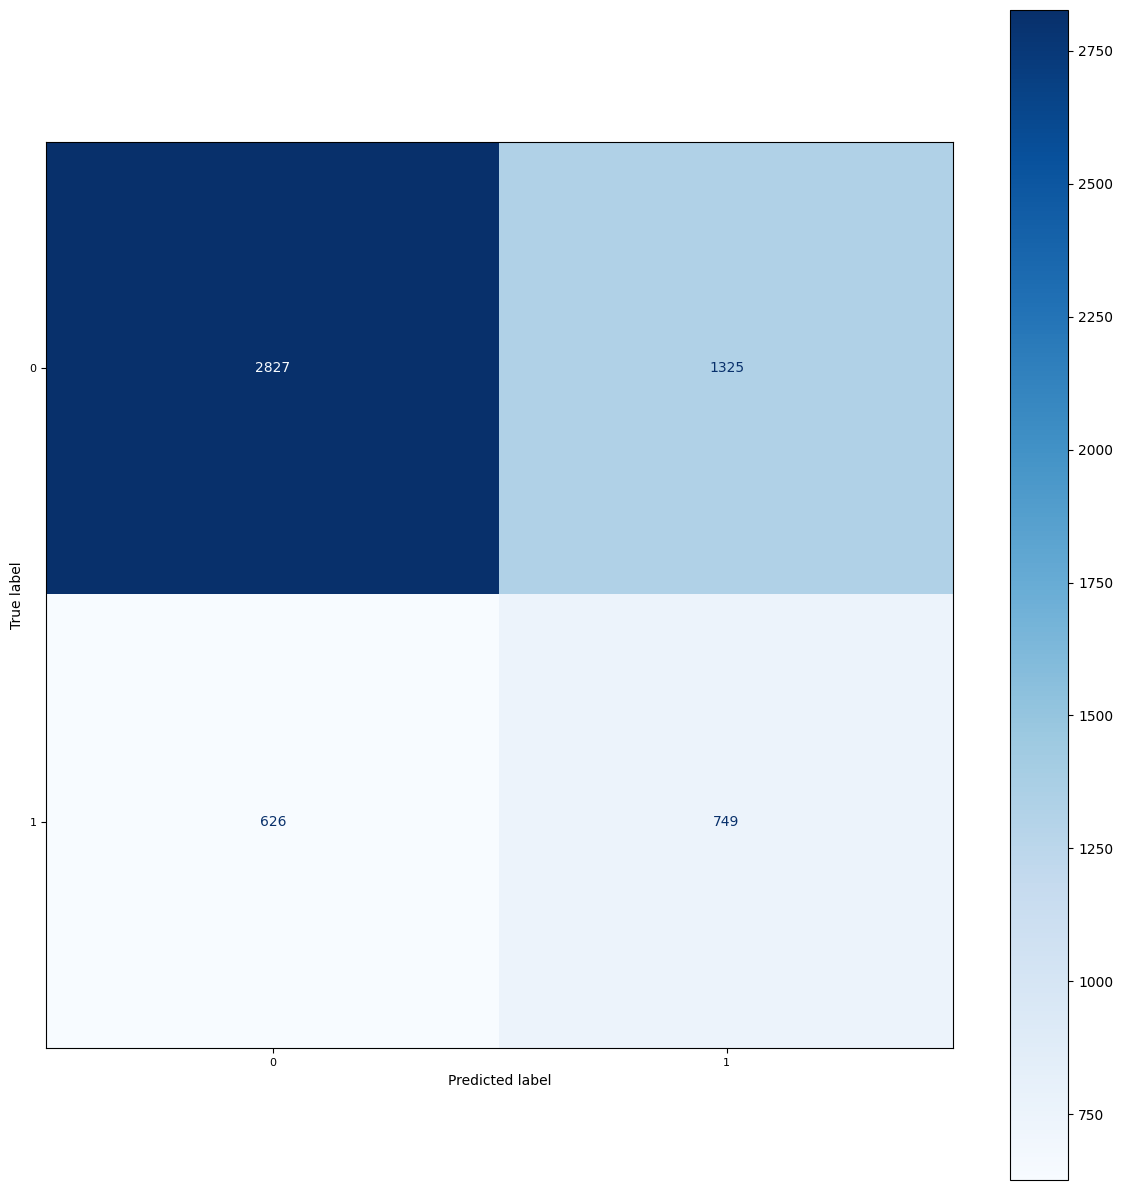

In [46]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

preds = [p for p, _ in metrics["predictions"]]
real = [p for _, p in metrics["predictions"]]

class_names = np.unique(real)
cm = confusion_matrix(real, preds, labels=class_names)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(12, 12))
disp.plot(ax=ax, cmap="Blues", colorbar=True)

plt.xticks(rotation=0, ha="center", fontsize=8)
plt.yticks(rotation=0, ha="right", fontsize=8)

plt.tight_layout()
plt.show()

In [29]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score, classification_report
import numpy as np

X_flat = features.reshape(features.shape[0], -1)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

candidates = {
    "svm_rbf_balanced": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="rbf", C=10, gamma="scale", class_weight="balanced")),
    ]),
    "svm_linear_balanced": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="linear", C=1.0, class_weight="balanced")),
    ]),
    "logreg_balanced": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced")),
    ]),
    "rf_balanced": RandomForestClassifier(
        n_estimators=500,
        random_state=42,
        class_weight="balanced_subsample",
        max_features="sqrt",
    ),
}

scores = {}
for name, model in candidates.items():
    y_pred = cross_val_predict(model, X_flat, y, cv=cv, n_jobs=-1)
    bacc = balanced_accuracy_score(y, y_pred)
    scores[name] = bacc
    print(f"{name}: balanced_accuracy={bacc:.4f}")

best_name = max(scores, key=scores.get)
print(f"\nBest candidate: {best_name} ({scores[best_name]:.4f})")

svm_rbf_balanced: balanced_accuracy=0.5139
svm_linear_balanced: balanced_accuracy=0.4981
logreg_balanced: balanced_accuracy=0.5099
rf_balanced: balanced_accuracy=0.4966

Best candidate: svm_rbf_balanced (0.5139)
